In [3]:
# read data
import pandas as pd

df_ptt = pd.read_csv("bda2025_202301-202503_討論數據_ptt.csv", encoding="utf-8")
df_dcard1 = pd.read_csv("bda2025_202301-202503_討論數據_dcard_1.csv", encoding="utf-8")
df_dcard2 = pd.read_csv("bda2025_202301-202503_討論數據_dcard_2.csv", encoding="utf-8")
df_mobile = pd.read_csv("bda2025_202301-202503_討論數據_mobile01.csv", encoding="utf-8")
df_news = pd.read_csv("bda2025_202301-202503_內容數據_新聞.csv", encoding="utf-8")
df_listed_dict = pd.read_excel("bda2025_stock_202301-202503_上市.xlsx", sheet_name=None)
df_OTC = pd.read_excel("bda2025_stock_202301-202503_上櫃.xlsx")

In [4]:
listed_list = []

for df in df_listed_dict.values():
    listed_list.append(df)

df_listed = pd.concat(listed_list, ignore_index=True)
df_listed

,代號,名稱,年月日,開盤價(元),最高價(元),最低價(元),收盤價(元),成交量(千股),成交值(千元),報酬率％,...,現金股利率,股價漲跌(元),高低價差%,次日開盤參考價,次日漲停價,次日跌停價,注意股票(A),處置股票(D),全額交割(Y),市場別
0,0050,元大台灣50,2023/06/30,121.7400,122.0236,121.2674,122.0236,7504,964915,0.0387,...,3.4082,0.05,0.6199,129.10,142.00,116.20,NaN,NaN,NaN,TSE
1,0051,元大中型100,2023/06/30,61.9155,62.1026,61.8688,62.0558,203,13462,0.3023,...,3.6172,0.20,0.3779,66.35,72.95,59.75,NaN,NaN,NaN,TSE
2,0052,富邦科技,2023/06/30,110.2080,111.4560,109.9680,111.4560,95,10974,0.5630,...,3.4453,0.65,1.3426,116.10,127.70,104.50,NaN,NaN,NaN,TSE
3,0053,元大電子,2023/06/30,63.3886,63.7224,63.3886,63.7224,3,211,0.5267,...,2.5599,0.35,0.5267,66.80,73.45,60.15,NaN,NaN,NaN,TSE
4,0055,元大MSCI金融,2023/06/30,21.7009,21.7383,21.6448,21.6728,95,2210,-0.1293,...,3.7549,-0.03,0.4310,23.17,25.48,20.86,NaN,NaN,NaN,TSE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763822,Y8886,未含金電,2025/01/02,14213.4700,14311.6000,14183.3400,14216.0900,1057906,79630084,0.0234,...,3.0885,3.32,0.9024,NaN,NaN,NaN,NaN,NaN,NaN,TSE
763823,Y8887,TR未金電,2025/01/02,NaN,NaN,NaN,32572.3200,1057906,79630084,0.0233,...,3.0885,7.60,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,TSE
763824,Y8888,不含金融,2025/01/02,20072.5600,20133.9300,19825.4500,19931.9200,2612064,325006568,-0.9846,...,2.3587,-198.21,1.5324,NaN,NaN,NaN,NaN,NaN,NaN,TSE
763825,Y9997,報酬指數,2025/01/02,50804.1100,50942.0100,50224.5900,50486.4600,6901476,379129283,-0.8187,...,2.4561,-416.77,1.4094,NaN,NaN,NaN,NaN,NaN,NaN,TSE


In [5]:
print(df_ptt.columns)
print(df_dcard1.columns)
print(df_dcard2.columns)
print(df_mobile.columns)
print(df_news.columns)

Index(['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author',
       'content', 'page_url'],
      dtype='object')
Index(['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author',
       'content', 'page_url', 'content_type'],
      dtype='object')
Index(['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author',
       'content', 'page_url', 'content_type'],
      dtype='object')
Index(['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author',
       'content', 'page_url', 'content_type'],
      dtype='object')
Index(['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author',
       'content', 'page_url'],
      dtype='object')


## Step 1: 先選出要預測的股票標的
- 篩選條件：股價波動大的股票
- 篩選方式：不知道他報酬率怎麼算出來的，但就是找出 Variance 報酬率最大的股票

### 1.1 找出股票波動最大的前50檔股票

In [6]:

variance_by_stock = df_listed.groupby("名稱")["報酬率％"].var().sort_values(ascending=False)

top50 = variance_by_stock.head(50)
for stock, variance in top50.items():
    stock = stock.strip()
    print(f"股票: {stock:7}", end="")
    print(f"報酬率變異數: {variance:.2f}")

stock_lists = []

for stock in top50.index:
    stock = stock.strip()
    stock_lists.append(stock)

股票: 三集瑞-KY 報酬率變異數: 118.14
股票: 裕慶-KY  報酬率變異數: 98.10
股票: 來億-KY  報酬率變異數: 94.47
股票: 龍德造船   報酬率變異數: 85.60
股票: AMAX-KY報酬率變異數: 83.21
股票: 永道-KY  報酬率變異數: 53.40
股票: ITH-KY 報酬率變異數: 50.09
股票: 華懋     報酬率變異數: 47.40
股票: 天虹     報酬率變異數: 38.04
股票: 星宇航空   報酬率變異數: 37.11
股票: 望隼     報酬率變異數: 35.65
股票: 富威電力   報酬率變異數: 32.56
股票: 富世達    報酬率變異數: 28.16
股票: 玖鼎電力   報酬率變異數: 26.18
股票: 虎山     報酬率變異數: 25.37
股票: 六方科-KY 報酬率變異數: 24.72
股票: 現觀科    報酬率變異數: 22.82
股票: 達運光電   報酬率變異數: 22.00
股票: 聯策     報酬率變異數: 21.09
股票: 青松健康   報酬率變異數: 19.86
股票: 睿生光電   報酬率變異數: 19.84
股票: 有成精密   報酬率變異數: 18.34
股票: 攸泰科技   報酬率變異數: 17.86
股票: 光聖     報酬率變異數: 17.78
股票: 華城     報酬率變異數: 16.83
股票: 銘旺科    報酬率變異數: 16.64
股票: 晟銘電    報酬率變異數: 16.41
股票: 迎廣     報酬率變異數: 16.23
股票: 康霈*    報酬率變異數: 16.17
股票: 金興精密   報酬率變異數: 16.09
股票: 阜爾運通   報酬率變異數: 15.68
股票: 華安     報酬率變異數: 14.49
股票: 麗臺     報酬率變異數: 14.22
股票: 高力     報酬率變異數: 14.04
股票: 訊芯-KY  報酬率變異數: 13.97
股票: 慧友     報酬率變異數: 13.64
股票: 世芯-KY  報酬率變異數: 13.54
股票: 皇昌     報酬率變異數: 13.36
股票: 威盛     報酬率變異數: 13.22
股票: 波力-KY  報酬率變異數: 13.07

### 1.2 再算出這五十檔股票的 term-frequency

In [7]:
import pandas as pd

class Source:
    def __init__(self, name, df):
        self.name = name
        self.df = df

class Company:
    def __init__(self, name):
        self.name = name

    def count_mentions_in(self, source):
        count = 0
        for content in source.df["content"]:
            if isinstance(content, str) and (self.name in content):
                count += 1
        return count

# Create source and company objects
sources = [
    Source("PTT", df_ptt),
    Source("Dcard1", df_dcard1),
    Source("Dcard2", df_dcard2),
    Source("Mobile01", df_mobile),
    Source("News", df_news)
]

companies = [Company(name) for name in stock_lists]

# Build a list of dicts (rows)
test_data = []
for company in companies:
    row = {"公司": company.name}
    total = 0
    for source in sources:
        count = company.count_mentions_in(source)
        row[source.name] = count
        total += count
    row["總計"] = total
    test_data.append(row)

summary_df = pd.DataFrame(test_data)
summary_df.sort_values(by="總計", ascending=False, inplace=True)

# drop=Ture 會讓原本的 index 消掉，不然就會有兩欄 index
summary_df.reset_index(drop=False, inplace=True, names="old")
summary_df

,old,公司,PTT,Dcard1,Dcard2,Mobile01,News,總計
0,45,創意,998,119,159,31,7004,8311
1,43,緯穎,831,91,187,6,4803,5918
2,36,世芯-KY,781,37,123,7,4252,5200
3,41,奇鋐,1120,101,179,4,3671,5075
4,24,華城,908,78,174,7,3220,4387
5,49,祥碩,322,30,111,1,2008,2472
6,46,勤誠,394,59,45,1,1619,2118
7,40,聯鈞,579,16,174,0,1234,2003
8,38,威盛,535,104,39,3,1232,1913
9,26,晟銘電,523,47,83,1,1192,1846


### Step 1 小結：預計選創意

## Step 2：跑 n-gram

### Step 2.1 從五個文章來源，篩選出所有 title, content 包含龍得造船的文章並存成一個新的 df

In [8]:
# 先篩出包含公司名稱的資料 ID
fileID_contain_companyname = []

for source in sources:
    for id, title, content in zip(source.df['id'], source.df["title"], source.df["content"]):
        if isinstance(title, str) and isinstance(content, str):
            title = title.strip()
            content = content.strip()
            if ("龍德造船" in title) or ("龍德造船" in content):
                fileID_contain_companyname.append(id)
            
print(fileID_contain_companyname)

['1678063187724_PTT02R', '1678246199548_PTT02R', '1678839412112_PTT02R', '1678840307061_PTT02R', '1679047950014_PTT02R', '1679142671637_PTT02R', '1679983265966_PTT02R', '1679991217391_PTT02R', '1679998663870_PTT02R', '1680851794815_PTT02R', '1680854765619_PTT02R', '1681034003974_PTT02R', '1681099929868_PTT02R', '1681797747889_PTT02R', '1682062709166_PTT02R', '1682239492693_PTT02R', '1682865865176_PTT02R', '1688022418193_PTT02R', '1691900348809_PTT02R', '1692764322055_PTT02R', '1694755081857_PTT02R', '1702159720091_PTT02R', '1705723747782_PTT02R', '1710498161710_PTT02R', '1711109633685_PTT02R', '1711374263848_PTT02R', '1711428133770_PTT02R', '1711516920282_PTT02R', '1711540285922_PTT02R', '1712152222987_PTT02R', '1713440859037_PTT02R', '1713458922300_PTT02R', '1713538789957_PTT02R', '1713761289122_PTT02R', '1714970302132_PTT02R', '1715143095906_PTT02R', '1715332849350_PTT02R', '1715685038289_PTT02R', '1715694221176_PTT02R', '1715788156738_PTT02R', '1718261656806_PTT02R', '1718794218564_

In [9]:
# 按照 ID 製作新的 dataframe
cleaned_ppt_df = df_ptt[df_ptt["id"].isin(fileID_contain_companyname)]
cleaned_dcard1_df = df_dcard1[df_dcard1["id"].isin(fileID_contain_companyname)].drop(columns=["content_type"])
cleaned_dcard2_df = df_dcard2[df_dcard2["id"].isin(fileID_contain_companyname)].drop(columns=["content_type"])
cleaned_mobile_df = df_mobile[df_mobile["id"].isin(fileID_contain_companyname)].drop(columns=["content_type"])
cleaned_news_df = df_news[df_news["id"].isin(fileID_contain_companyname)]
cleaned_ppt_df['source'] = 'PTT'
cleaned_dcard1_df['source'] = 'Dcard1'
cleaned_dcard2_df['source'] = 'Dcard2'
cleaned_mobile_df['source'] = 'Mobile01'
cleaned_news_df['source'] = 'News'
cleaned_df = pd.concat([cleaned_ppt_df, cleaned_dcard1_df, cleaned_dcard2_df, cleaned_mobile_df, cleaned_news_df], ignore_index=True)
cleaned_df

/var/folders/yt/6_xzvtrx40vg93_r3y7kdjtc0000gn/T/ipykernel_70874/893529480.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_ppt_df['source'] = 'PTT'
/var/folders/yt/6_xzvtrx40vg93_r3y7kdjtc0000gn/T/ipykernel_70874/893529480.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_news_df['source'] = 'News'


,id,p_type,s_name,s_area_name,post_time,title,author,content,page_url,source
0,1678063187724_PTT02R,bbs,Ptt,Stock,2023-03-06 08:37:42,[新聞] 龍德造船 長榮航太 永豐金 抽籤再現熱潮,ej03xu3,原文標題：三炮齊發 新股抽籤再現熱潮 原文連結：https://reurl.cc/WD1j...,http://www.ptt.cc/bbs/Stock/M.1678063065.A.BDE...,PTT
1,1678246199548_PTT02R,bbs,Ptt,Stock,2023-03-08 11:27:49,[新聞] 長榮航太也槓龜？錢存起來抽這檔 1.5月薪,TT991,原文標題：長榮航太也槓龜？錢存起來抽這檔 1.5月薪躺著賺 原文連結：https://yn...,http://www.ptt.cc/bbs/Stock/M.1678246071.A.0FF...,PTT
2,1678839412112_PTT02R,bbs,Ptt,Stock,2023-03-15 08:15:04,[新聞] 詐團騙中50張龍德造船新股 老翁險匯150萬,starport,詐團騙中50張龍德造船新股 老翁險匯150萬遭警阻 https://bit.ly/404P...,http://www.ptt.cc/bbs/Stock/M.1678839307.A.215...,PTT
3,1678840307061_PTT02R,bbs,Ptt,Stock,2023-03-15 08:28:32,[新聞] 睿生光電 申購今登場 中籤者現賺於6萬,ej03xu3,原文標題：蜜月行情超甜 新股抽籤熱再起 原文連結：https://reurl.cc/Nq4...,http://www.ptt.cc/bbs/Stock/M.1678840115.A.B9B...,PTT
4,1679047950014_PTT02R,bbs,Ptt,Stock,2023-03-17 18:10:33,[情報] 112/03/17 八大公股銀行買賣超排行,q1a1,1. 標題：112/03/17 八大公股銀行買賣超排行 2. 來源：玩股網 3. 網址：...,http://www.ptt.cc/bbs/Stock/M.1679047835.A.285...,PTT
...,...,...,...,...,...,...,...,...,...,...
744,1737678910949_YahooStock,news,Yahoo股市,財經新聞,2025-01-24 08:26:35,《熱門族群》川普帶動國防支出 航太軍工熱,時報資訊,【時報-台北電】隨著川普2.0的時代到來，日本、南韓、澳洲、印度、台灣等環太平洋國家緊繃的神...,https://tw.stock.yahoo.com/news/%E7%86%B1%E9%9...,News
745,1739174274749_YahooStock,news,Yahoo股市,財經新聞,2025-02-10 15:42:54,【公告】龍德造船 2025年1月合併營收4.86億元 年增39.77%,中央社,日期： 2025 年 02 月 10日上市公司：龍德造船 (6753)單位：仟元【公告】龍德...,https://tw.stock.yahoo.com/news/%E5%85%AC%E5%9...,News
746,1739517652218_YahooStock,news,Yahoo股市,財經新聞,2025-02-14 15:14:26,《台北股市》川普搞破壞 外資揮今年第六大刀 三大法人砍304億,時報資訊,【時報-台北電】川普投顧又來亂，再提晶片關稅政策，衝擊台股重挫246點月線警鈴大作，今日三大...,https://tw.stock.yahoo.com/news/%E5%8F%B0%E5%8...,News
747,1739828103962_YahooStock,news,Yahoo股市,財經新聞,2025-02-18 04:10:00,勇鷹高教機失事 漢翔 面臨營運陣痛期,劉朱松／台中報導,勇鷹高教機失事利空衝擊漢翔（2634）股價，漢翔17日回應，肇因調查由空軍主導，漢翔全力配合...,https://tw.stock.yahoo.com/news/%E5%8B%87%E9%B...,News


### 清除 title, content 中的表點符號、英文、數字；將日期轉換格式

In [10]:
import re
def clean_text(text):
    """Remove punctuation, English letters, and digits"""
    text = re.sub(r"[^\u4e00-\u9fa5]", "", text)
    return text

cleaned_df["title"] = cleaned_df["title"].apply(clean_text)
cleaned_df["content"] = cleaned_df["content"].apply(clean_text)
cleaned_df


,id,p_type,s_name,s_area_name,post_time,title,author,content,page_url,source
0,1678063187724_PTT02R,bbs,Ptt,Stock,2023-03-06 08:37:42,新聞龍德造船長榮航太永豐金抽籤再現熱潮,ej03xu3,原文標題三炮齊發新股抽籤再現熱潮原文連結發布時間年月日週一記者署名工商時報鄭郁平原文內容台股...,http://www.ptt.cc/bbs/Stock/M.1678063065.A.BDE...,PTT
1,1678246199548_PTT02R,bbs,Ptt,Stock,2023-03-08 11:27:49,新聞長榮航太也槓龜錢存起來抽這檔月薪,TT991,原文標題長榮航太也槓龜錢存起來抽這檔月薪躺著賺原文連結發布時間年月日週三上午記者署名龍彩霖原...,http://www.ptt.cc/bbs/Stock/M.1678246071.A.0FF...,PTT
2,1678839412112_PTT02R,bbs,Ptt,Stock,2023-03-15 08:15:04,新聞詐團騙中張龍德造船新股老翁險匯萬,starport,詐團騙中張龍德造船新股老翁險匯萬遭警阻高華謙詐騙集團看準原興櫃股龍德造船公開申購期間湧現買氣...,http://www.ptt.cc/bbs/Stock/M.1678839307.A.215...,PTT
3,1678840307061_PTT02R,bbs,Ptt,Stock,2023-03-15 08:28:32,新聞睿生光電申購今登場中籤者現賺於萬,ej03xu3,原文標題蜜月行情超甜新股抽籤熱再起原文連結發布時間記者署名工商時報鄭郁平原文內容新股抽抽樂再...,http://www.ptt.cc/bbs/Stock/M.1678840115.A.B9B...,PTT
4,1679047950014_PTT02R,bbs,Ptt,Stock,2023-03-17 18:10:33,情報八大公股銀行買賣超排行,q1a1,標題八大公股銀行買賣超排行來源玩股網網址內文以下資訊依張數排列買超賣超排名股票張數排名股票張...,http://www.ptt.cc/bbs/Stock/M.1679047835.A.285...,PTT
...,...,...,...,...,...,...,...,...,...,...
744,1737678910949_YahooStock,news,Yahoo股市,財經新聞,2025-01-24 08:26:35,熱門族群川普帶動國防支出航太軍工熱,時報資訊,時報台北電隨著川普的時代到來日本南韓澳洲印度台灣等環太平洋國家緊繃的神經再度拴緊回顧年川普上...,https://tw.stock.yahoo.com/news/%E7%86%B1%E9%9...,News
745,1739174274749_YahooStock,news,Yahoo股市,財經新聞,2025-02-10 15:42:54,公告龍德造船年月合併營收億元年增,中央社,日期年月日上市公司龍德造船單位仟元公告龍德造船年月合併營收單位仟元項目合併營業收入淨額本月去...,https://tw.stock.yahoo.com/news/%E5%85%AC%E5%9...,News
746,1739517652218_YahooStock,news,Yahoo股市,財經新聞,2025-02-14 15:14:26,台北股市川普搞破壞外資揮今年第六大刀三大法人砍億,時報資訊,時報台北電川普投顧又來亂再提晶片關稅政策衝擊台股重挫點月線警鈴大作今日三大法人同步作空外資不...,https://tw.stock.yahoo.com/news/%E5%8F%B0%E5%8...,News
747,1739828103962_YahooStock,news,Yahoo股市,財經新聞,2025-02-18 04:10:00,勇鷹高教機失事漢翔面臨營運陣痛期,劉朱松／台中報導,勇鷹高教機失事利空衝擊漢翔股價漢翔日回應肇因調查由空軍主導漢翔全力配合辦理有外界指稱位於岡山...,https://tw.stock.yahoo.com/news/%E5%8B%87%E9%B...,News


### 開始切字

In [11]:
def char_tokenize(text):
    """
    Returns a list of characters (including punctuation/spaces).
    For purely Chinese text, this effectively splits into single-character tokens.
    """
    return list(text)

def generate_ngrams(tokens, n):
    """
    Given a list of tokens (characters or words) and integer n,
    yields each contiguous n-gram.
    """
    for i in range(len(tokens) - n + 1):
        yield tuple(tokens[i : i + n])

test_data = {
    "content": [
        "你好世界",          # Hello world
        "世界上的熊貓",      # Pandas in the world
        "你好熊貓世界",      # Hello panda world
        "測試熊貓功能",      # Test panda functions
        "再次你好"           # Hello again
    ]
}

test_df = pd.DataFrame(test_data)

unique_ngrams = set()

for content in cleaned_df["content"]:
    if isinstance(content, str):
        content = content.strip()
        tokens = char_tokenize(content)
        for ngram in generate_ngrams(tokens, 2):
            tmp = ''.join(ngram)
            unique_ngrams.add(tmp)
        for ngram in generate_ngrams(tokens, 3):
            tmp = ''.join(ngram)
            unique_ngrams.add(tmp)
        for ngram in generate_ngrams(tokens, 4):
            tmp = ''.join(ngram)
            unique_ngrams.add(tmp)

# Then count each unique trigram
frequencies = []
for ngram in unique_ngrams:
    freq = cleaned_df["content"].str.count(ngram).sum()
    frequencies.append({"word": ngram, "term_frequency": freq})

frequencies_df = pd.DataFrame(frequencies)
frequencies_df.sort_values(by="term_frequency", ascending=False, inplace=True)
frequencies_df.reset_index(drop=True, inplace=True)
frequencies_df.head(10)

,word,term_frequency
0,股價,2182
1,指數,1825
2,億元,1570
3,造船,1307
4,台股,1185
5,上漲,1164
6,龍德,1141
7,德造,1050
8,龍德造,1049
9,德造船,1048


In [17]:
key_words = frequencies_df.head(100)["word"].tolist()
print(key_words)

['股價', '指數', '億元', '造船', '台股', '上漲', '龍德', '德造', '龍德造', '德造船', '龍德造船', '表現', '軍工', '下跌', '市場', '積電', '台積', '台積電', '營收', '公司', '美國', '漲停', '今年', '今日', '族群', '新高', '台灣', '持續', '震盪', '漲幅', '外資', '航太', '長榮', '成交', '電子', '產業', '法人', '投資', '買超', '概念', '題材', '類股', '相關', '超億', '科技', '成長', '股市', '超億元', '強勢', '盤中', '個股', '月日', '預期', '上市', '去年', '不過', '能源', '美股', '概念股', '念股', '一度', '賣超', '漢翔', '指標', '終場', '交易', '大漲', '長榮航', '榮航', '帶動', '第一', '半導體', '半導', '導體', '三大', '交量', '加權', '成交量', '早盤', '工股', '受惠', '獲利', '軍工股', '國防', '半年', '短線', '違規', '反彈', '目前', '資金', '收在', '跌幅', '上週', '權指', '加權指', '超過', '加權指數', '權指數', '台北', '近期']


### 將文章標記成看漲文章或是看跌文章

In [18]:
# 先將 "年月日" 轉換為 datetime 格式
df_listed_selected = df_listed[df_listed["代號"] == "6753"]
df_listed_selected = df_listed_selected[["年月日", "報酬率％"]]
df_listed_selected["年月日"] = pd.to_datetime(df_listed_selected["年月日"], format="%Y/%m/%d")
df_listed_selected

,年月日,報酬率％
1065,2023-06-30,-1.9231
2496,2023-06-29,2.9703
3927,2023-06-28,0.4975
5358,2023-06-27,-3.3654
6789,2023-06-26,0.0000
...,...,...
757180,2025-01-08,-1.9512
758731,2025-01-07,1.4851
760282,2025-01-06,0.0000
761833,2025-01-03,-0.4926


In [46]:
def clean_time(time):
    time = time.split(" ")
    return time[0]

# 將時間去掉小時、分鐘、秒只留下日期
try:
    cleaned_df["post_time"] = cleaned_df["post_time"].apply(clean_time)
except:
    pass

# 將 "post_time" 也轉換為 datetime 格式
cleaned_df["post_time"] = pd.to_datetime(cleaned_df["post_time"], format="%Y-%m-%d")
# 新增一欄 "mark"，預設為 0
cleaned_df['mark'] = 0

cleaned_df

,id,p_type,s_name,s_area_name,post_time,title,author,content,page_url,source,mark
0,1678063187724_PTT02R,bbs,Ptt,Stock,2023-03-06,新聞龍德造船長榮航太永豐金抽籤再現熱潮,ej03xu3,原文標題三炮齊發新股抽籤再現熱潮原文連結發布時間年月日週一記者署名工商時報鄭郁平原文內容台股...,http://www.ptt.cc/bbs/Stock/M.1678063065.A.BDE...,PTT,0
1,1678246199548_PTT02R,bbs,Ptt,Stock,2023-03-08,新聞長榮航太也槓龜錢存起來抽這檔月薪,TT991,原文標題長榮航太也槓龜錢存起來抽這檔月薪躺著賺原文連結發布時間年月日週三上午記者署名龍彩霖原...,http://www.ptt.cc/bbs/Stock/M.1678246071.A.0FF...,PTT,0
2,1678839412112_PTT02R,bbs,Ptt,Stock,2023-03-15,新聞詐團騙中張龍德造船新股老翁險匯萬,starport,詐團騙中張龍德造船新股老翁險匯萬遭警阻高華謙詐騙集團看準原興櫃股龍德造船公開申購期間湧現買氣...,http://www.ptt.cc/bbs/Stock/M.1678839307.A.215...,PTT,0
3,1678840307061_PTT02R,bbs,Ptt,Stock,2023-03-15,新聞睿生光電申購今登場中籤者現賺於萬,ej03xu3,原文標題蜜月行情超甜新股抽籤熱再起原文連結發布時間記者署名工商時報鄭郁平原文內容新股抽抽樂再...,http://www.ptt.cc/bbs/Stock/M.1678840115.A.B9B...,PTT,0
4,1679047950014_PTT02R,bbs,Ptt,Stock,2023-03-17,情報八大公股銀行買賣超排行,q1a1,標題八大公股銀行買賣超排行來源玩股網網址內文以下資訊依張數排列買超賣超排名股票張數排名股票張...,http://www.ptt.cc/bbs/Stock/M.1679047835.A.285...,PTT,0
...,...,...,...,...,...,...,...,...,...,...,...
744,1737678910949_YahooStock,news,Yahoo股市,財經新聞,2025-01-24,熱門族群川普帶動國防支出航太軍工熱,時報資訊,時報台北電隨著川普的時代到來日本南韓澳洲印度台灣等環太平洋國家緊繃的神經再度拴緊回顧年川普上...,https://tw.stock.yahoo.com/news/%E7%86%B1%E9%9...,News,0
745,1739174274749_YahooStock,news,Yahoo股市,財經新聞,2025-02-10,公告龍德造船年月合併營收億元年增,中央社,日期年月日上市公司龍德造船單位仟元公告龍德造船年月合併營收單位仟元項目合併營業收入淨額本月去...,https://tw.stock.yahoo.com/news/%E5%85%AC%E5%9...,News,0
746,1739517652218_YahooStock,news,Yahoo股市,財經新聞,2025-02-14,台北股市川普搞破壞外資揮今年第六大刀三大法人砍億,時報資訊,時報台北電川普投顧又來亂再提晶片關稅政策衝擊台股重挫點月線警鈴大作今日三大法人同步作空外資不...,https://tw.stock.yahoo.com/news/%E5%8F%B0%E5%8...,News,0
747,1739828103962_YahooStock,news,Yahoo股市,財經新聞,2025-02-18,勇鷹高教機失事漢翔面臨營運陣痛期,劉朱松／台中報導,勇鷹高教機失事利空衝擊漢翔股價漢翔日回應肇因調查由空軍主導漢翔全力配合辦理有外界指稱位於岡山...,https://tw.stock.yahoo.com/news/%E5%8B%87%E9%B...,News,0


In [48]:
for idx, (date, mark) in enumerate(zip(cleaned_df['post_time'], cleaned_df['mark'])):
    # print(f'date: {date}, mark: {mark}')
    row = df_listed_selected[df_listed_selected['年月日'] == date]
    # print(f'row {row}')
    
    if row.empty:
        continue
    
    new_mark = int(row['報酬率％'].values[0] > 0)
    # print(f'mark: {new_mark}')
    
    cleaned_df.loc[idx, 'mark'] = new_mark
    # print("\n")

cleaned_df

,id,p_type,s_name,s_area_name,post_time,title,author,content,page_url,source,mark
0,1678063187724_PTT02R,bbs,Ptt,Stock,2023-03-06,新聞龍德造船長榮航太永豐金抽籤再現熱潮,ej03xu3,原文標題三炮齊發新股抽籤再現熱潮原文連結發布時間年月日週一記者署名工商時報鄭郁平原文內容台股...,http://www.ptt.cc/bbs/Stock/M.1678063065.A.BDE...,PTT,0
1,1678246199548_PTT02R,bbs,Ptt,Stock,2023-03-08,新聞長榮航太也槓龜錢存起來抽這檔月薪,TT991,原文標題長榮航太也槓龜錢存起來抽這檔月薪躺著賺原文連結發布時間年月日週三上午記者署名龍彩霖原...,http://www.ptt.cc/bbs/Stock/M.1678246071.A.0FF...,PTT,0
2,1678839412112_PTT02R,bbs,Ptt,Stock,2023-03-15,新聞詐團騙中張龍德造船新股老翁險匯萬,starport,詐團騙中張龍德造船新股老翁險匯萬遭警阻高華謙詐騙集團看準原興櫃股龍德造船公開申購期間湧現買氣...,http://www.ptt.cc/bbs/Stock/M.1678839307.A.215...,PTT,1
3,1678840307061_PTT02R,bbs,Ptt,Stock,2023-03-15,新聞睿生光電申購今登場中籤者現賺於萬,ej03xu3,原文標題蜜月行情超甜新股抽籤熱再起原文連結發布時間記者署名工商時報鄭郁平原文內容新股抽抽樂再...,http://www.ptt.cc/bbs/Stock/M.1678840115.A.B9B...,PTT,1
4,1679047950014_PTT02R,bbs,Ptt,Stock,2023-03-17,情報八大公股銀行買賣超排行,q1a1,標題八大公股銀行買賣超排行來源玩股網網址內文以下資訊依張數排列買超賣超排名股票張數排名股票張...,http://www.ptt.cc/bbs/Stock/M.1679047835.A.285...,PTT,1
...,...,...,...,...,...,...,...,...,...,...,...
744,1737678910949_YahooStock,news,Yahoo股市,財經新聞,2025-01-24,熱門族群川普帶動國防支出航太軍工熱,時報資訊,時報台北電隨著川普的時代到來日本南韓澳洲印度台灣等環太平洋國家緊繃的神經再度拴緊回顧年川普上...,https://tw.stock.yahoo.com/news/%E7%86%B1%E9%9...,News,0
745,1739174274749_YahooStock,news,Yahoo股市,財經新聞,2025-02-10,公告龍德造船年月合併營收億元年增,中央社,日期年月日上市公司龍德造船單位仟元公告龍德造船年月合併營收單位仟元項目合併營業收入淨額本月去...,https://tw.stock.yahoo.com/news/%E5%85%AC%E5%9...,News,0
746,1739517652218_YahooStock,news,Yahoo股市,財經新聞,2025-02-14,台北股市川普搞破壞外資揮今年第六大刀三大法人砍億,時報資訊,時報台北電川普投顧又來亂再提晶片關稅政策衝擊台股重挫點月線警鈴大作今日三大法人同步作空外資不...,https://tw.stock.yahoo.com/news/%E5%8F%B0%E5%8...,News,1
747,1739828103962_YahooStock,news,Yahoo股市,財經新聞,2025-02-18,勇鷹高教機失事漢翔面臨營運陣痛期,劉朱松／台中報導,勇鷹高教機失事利空衝擊漢翔股價漢翔日回應肇因調查由空軍主導漢翔全力配合辦理有外界指稱位於岡山...,https://tw.stock.yahoo.com/news/%E5%8B%87%E9%B...,News,1


### 建構向量空間
針對每篇文章，計算不同關鍵字出現的分數


In [49]:
df = cleaned_df[["id", "post_time", "mark"]]
df

,id,post_time,mark
0,1678063187724_PTT02R,2023-03-06,0
1,1678246199548_PTT02R,2023-03-08,0
2,1678839412112_PTT02R,2023-03-15,1
3,1678840307061_PTT02R,2023-03-15,1
4,1679047950014_PTT02R,2023-03-17,1
...,...,...,...
744,1737678910949_YahooStock,2025-01-24,0
745,1739174274749_YahooStock,2025-02-10,0
746,1739517652218_YahooStock,2025-02-14,1
747,1739828103962_YahooStock,2025-02-18,1


In [50]:
for col in key_words:
    df.loc[:, col] = 0  # 原本應該是 df[col] = 0，但這樣可以避免錯誤訊息

for idx, row in cleaned_df.iterrows():
    content = row["content"]
    for key in key_words:
        if isinstance(content, str):
            df.at[idx, key] = content.count(key)
df

/var/folders/yt/6_xzvtrx40vg93_r3y7kdjtc0000gn/T/ipykernel_70874/141970406.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = 0  # 原本應該是 df[col] = 0，但這樣可以避免錯誤訊息
/var/folders/yt/6_xzvtrx40vg93_r3y7kdjtc0000gn/T/ipykernel_70874/141970406.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = 0  # 原本應該是 df[col] = 0，但這樣可以避免錯誤訊息
/var/folders/yt/6_xzvtrx40vg93_r3y7kdjtc0000gn/T/ipykernel_70874/141970406.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

,id,post_time,mark,股價,指數,億元,造船,台股,上漲,龍德,...,收在,跌幅,上週,權指,加權指,超過,加權指數,權指數,台北,近期
0,1678063187724_PTT02R,2023-03-06,0,1,0,1,4,3,0,4,...,0,0,0,0,0,0,0,0,0,1
1,1678246199548_PTT02R,2023-03-08,0,0,0,4,1,1,0,2,...,0,0,0,0,0,0,0,0,0,0
2,1678839412112_PTT02R,2023-03-15,1,0,0,0,6,0,0,6,...,0,0,0,0,0,1,0,0,0,0
3,1678840307061_PTT02R,2023-03-15,1,3,0,0,2,3,0,2,...,0,0,0,0,0,0,0,0,0,1
4,1679047950014_PTT02R,2023-03-17,1,0,0,0,2,0,0,2,...,0,0,0,0,0,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,1737678910949_YahooStock,2025-01-24,0,1,0,3,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
745,1739174274749_YahooStock,2025-02-10,0,0,0,0,2,0,0,2,...,0,0,0,0,0,0,0,0,0,0
746,1739517652218_YahooStock,2025-02-14,1,0,2,8,1,4,0,1,...,1,0,0,0,0,0,0,0,1,1
747,1739828103962_YahooStock,2025-02-18,1,3,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


### 模型建置


Naive Bayes Classifier:
Accuracy: 0.47333333333333333
              precision    recall  f1-score   support

           0       0.48      0.83      0.61        75
           1       0.41      0.12      0.19        75

    accuracy                           0.47       150
   macro avg       0.45      0.47      0.40       150
weighted avg       0.45      0.47      0.40       150



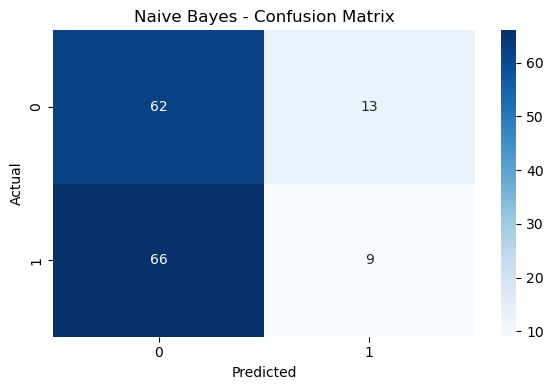


KNN Classifier:
Accuracy: 0.56
              precision    recall  f1-score   support

           0       0.56      0.56      0.56        75
           1       0.56      0.56      0.56        75

    accuracy                           0.56       150
   macro avg       0.56      0.56      0.56       150
weighted avg       0.56      0.56      0.56       150



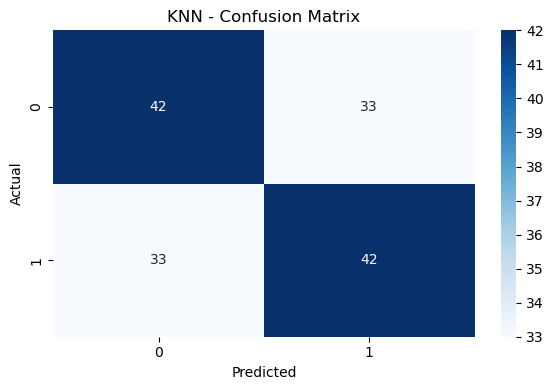


SVM Classifier:
Accuracy: 0.56
              precision    recall  f1-score   support

           0       0.55      0.64      0.59        75
           1       0.57      0.48      0.52        75

    accuracy                           0.56       150
   macro avg       0.56      0.56      0.56       150
weighted avg       0.56      0.56      0.56       150



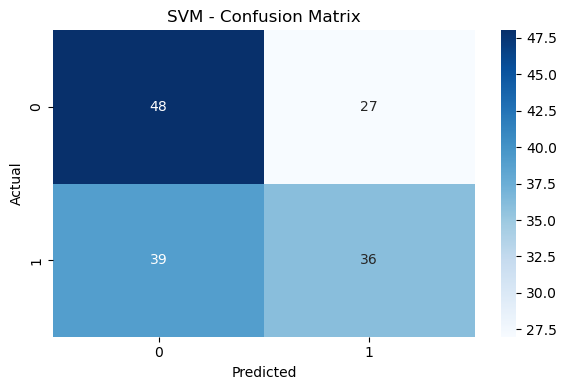


Decision Tree Classifier:
Accuracy: 0.58
              precision    recall  f1-score   support

           0       0.58      0.57      0.58        75
           1       0.58      0.59      0.58        75

    accuracy                           0.58       150
   macro avg       0.58      0.58      0.58       150
weighted avg       0.58      0.58      0.58       150



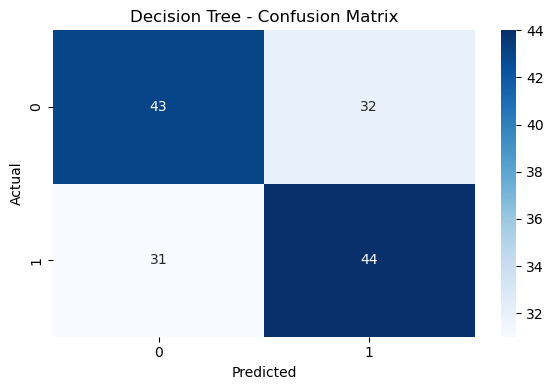


Random Forest Classifier:
Accuracy: 0.5933333333333334
              precision    recall  f1-score   support

           0       0.59      0.61      0.60        75
           1       0.60      0.57      0.59        75

    accuracy                           0.59       150
   macro avg       0.59      0.59      0.59       150
weighted avg       0.59      0.59      0.59       150



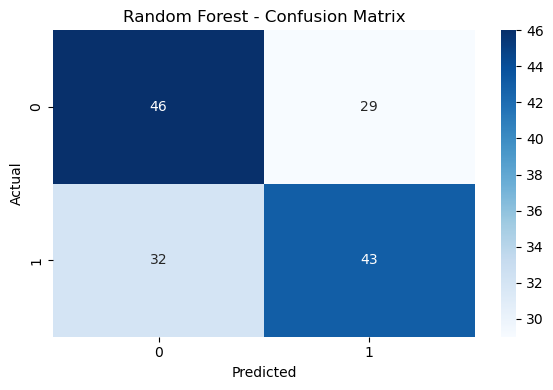

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Assume the target column is named 'target'
X = df.drop(['mark', 'id', 'post_time'], axis=1)  # Features
y = df['mark']              # Target

# 1. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optional: Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Initialize classifiers
models = {
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# 3. Train, evaluate, and plot confusion matrix
for name, model in models.items():
    if name in ['KNN', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Evaluation
    print(f"\n{name} Classifier:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()